In [ ]:
# pip install qiskit qiskit-aer matplotlib


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vmuno\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [53]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, Operator
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector
import matplotlib.pyplot as plt

# Helper function to convert DensityMatrix to Bloch vector
def density_matrix_to_bloch_vector(rho):
    """Convert a single-qubit DensityMatrix to a Bloch vector [x, y, z]"""
    # Pauli matrices
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    
    # Extract the density matrix as numpy array
    rho_matrix = rho.data
    
    # Compute expectation values: Tr(ρ·σ) where σ ∈ {X, Y, Z}
    x = np.real(np.trace(rho_matrix @ X))
    y = np.real(np.trace(rho_matrix @ Y))
    z = np.real(np.trace(rho_matrix @ Z))
    
    return np.array([x, y, z])


In [64]:
# ============================================================================
# DEFINE YOUR INPUT STATE HERE
# ============================================================================

# Method 1: Use a predefined label (e.g., '0', '1', '+', '-', 'r' for |+i⟩, 'l' for |-i⟩)
use_custom_state = False  # Set to True to use Method 2
input_state_label = '+'  # Options: '0', '1', '+', '-', 'r', 'l'

# Method 2: Provide a custom statevector as a numpy array
# Examples:
# np.array([1, 0])                    # |0⟩
# np.array([0, 1])                    # |1⟩
# np.array([1/np.sqrt(2), 1/np.sqrt(2)])      # |+⟩
# np.array([1/np.sqrt(2), -1/np.sqrt(2)])     # |-⟩
# np.array([1/np.sqrt(2), 1j/np.sqrt(2)])     # |+i⟩
# np.array([1/np.sqrt(2), -1j/np.sqrt(2)])    # |-i⟩
# np.array([np.cos(θ/2), np.exp(1j*φ)*np.sin(θ/2)])  # Arbitrary state
input_state_vector = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Default: |+⟩

# Create the statevector
if use_custom_state:
    state_before = Statevector(input_state_vector)
    input_state_label = 'custom'  # For labeling purposes
    print(f"Using custom input state: {state_before}")
else:
    state_before = Statevector.from_label(input_state_label)
    print(f"Using predefined state: {state_before}")
    print(f"Available labels: '0', '1', '+', '-', 'r' (|+i⟩), 'l' (|-i⟩)")
    print(f"Or set use_custom_state=True and provide input_state_vector")


Using predefined state: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Available labels: '0', '1', '+', '-', 'r' (|+i⟩), 'l' (|-i⟩)
Or set use_custom_state=True and provide input_state_vector


In [70]:
gate = 'Z'
# Other options: 'X', 'Y', 'H', 'S', 'T', 'CNOT', 'SWAP', 'CCNOT', 'CSWAP'

# Apply Z gate to the input state
# Z gate matrix: [[1, 0], [0, -1]]
gate = Operator.from_label(gate)
state_after = state_before.evolve(gate)

print(f"State before Z gate: {state_before}")


State before Z gate: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [71]:
print(f"State after Z gate: {state_after}")

# Determine the state labels for display
state_labels = {
    '0': ('|0⟩', '|0⟩'),  # Z|0⟩ = |0⟩ (no change)
    '1': ('|1⟩', '-|1⟩'),  # Z|1⟩ = -|1⟩ (phase flip, but physically same as |1⟩)
    '+': ('|+⟩', '|-⟩'),  # Z|+⟩ = |-⟩
    '-': ('|-⟩', '|+⟩'),  # Z|-⟩ = |+⟩
    'r': ('|+i⟩', '|-i⟩'),  # Z|+i⟩ = |-i⟩
    'l': ('|-i⟩', '|+i⟩'),  # Z|-i⟩ = |+i⟩
}

if input_state_label in state_labels:
    before_label, after_label = state_labels[input_state_label]
else:
    before_label = "Custom state"
    after_label = "After Z gate"


State after Z gate: Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [72]:
# Convert Statevector to DensityMatrix for plotting
# For a single qubit, we can convert directly
from qiskit.quantum_info import DensityMatrix

rho_before = DensityMatrix(state_before)
rho_after = DensityMatrix(state_after)


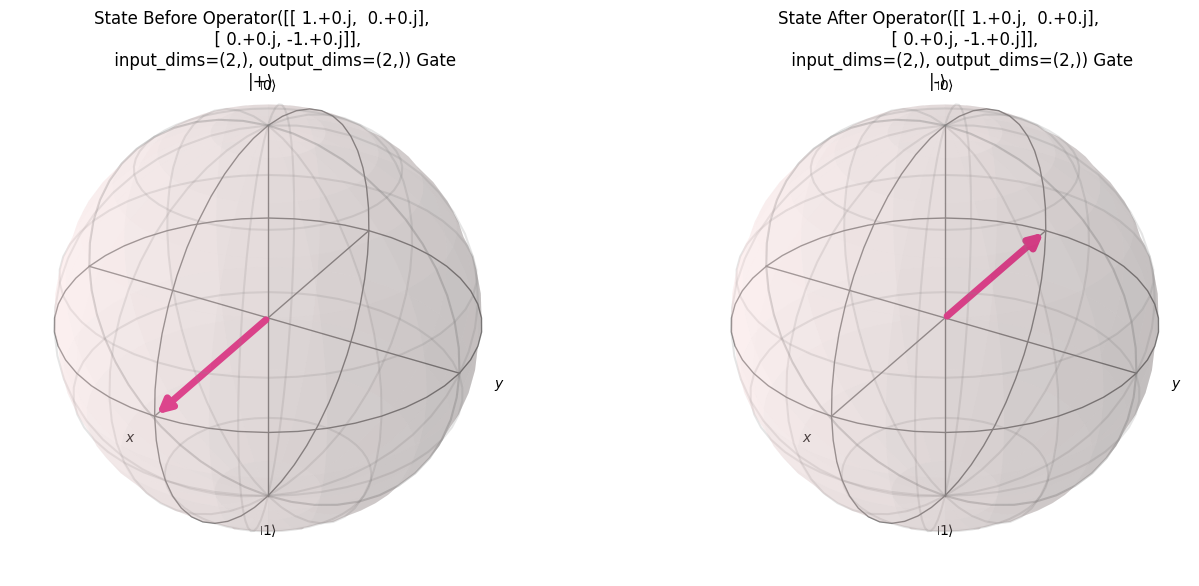


Bloch vectors:
Before Operator([[ 1.+0.j,  0.+0.j],
          [ 0.+0.j, -1.+0.j]],
         input_dims=(2,), output_dims=(2,)) gate: [1. 0. 0.]
After Operator([[ 1.+0.j,  0.+0.j],
          [ 0.+0.j, -1.+0.j]],
         input_dims=(2,), output_dims=(2,)) gate: [-1.  0.  0.]
Transformation: |+⟩ → |-⟩


In [73]:
# Create a figure with two subplots side by side
fig = plt.figure(figsize=(14, 6))

# Left: State before Z gate
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
bloch_vec_before = density_matrix_to_bloch_vector(rho_before)
plot_bloch_vector(bloch_vec_before, ax=ax1)
ax1.set_title(f"State Before {gate} Gate\n{before_label}", pad=20, fontsize=12)

# Right: State after Z gate
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
bloch_vec_after = density_matrix_to_bloch_vector(rho_after)
plot_bloch_vector(bloch_vec_after, ax=ax2)
ax2.set_title(f"State After {gate} Gate\n{after_label}", pad=20, fontsize=12)

plt.tight_layout()
plt.show()

# Print the Bloch vectors
print("\nBloch vectors:")
print(f"Before {gate} gate: {bloch_vec_before}")
print(f"After {gate} gate: {bloch_vec_after}")
print(f"Transformation: {before_label} → {after_label}")
